# **DEPRECATED** — use `notebooks/dermamnist_full_validation.ipynb` instead.

# Final Experiment: Optimization-History Memory for Clinical Failure Detection and Human Deferral

Tests whether optimization-history memory novelty **N(x)** complements predictive entropy **H(x)** for failure detection under clinical distribution shift and selective prediction / human deferral.

Compares three scorers: **H**, **N**, and **H+N** (calibration-only logistic).

> Edit the **Configuration** cell below before running. All paths and experiment knobs are centralized there.

## Configuration

Change only this cell to control the experiment.

In [4]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import sys

def _find_repo_root(cwd: Path | None = None) -> Path:
    """Resolve repo root whether the notebook cwd is repo root or notebooks/."""
    root = Path(cwd or Path.cwd()).resolve()
    if (root / "research").exists():
        return root
    if (root.parent / "research").exists():
        return root.parent
    return root


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.common.clinical_failure import FinalClinicalConfig

cfg = FinalClinicalConfig(
    seeds=(42, 123, 456),
    # organamnist omitted for now; add back after pathmnist+dermamnist finish.
    datasets=("pathmnist", "dermamnist"),
    bootstrap_replicates=2000,
    target_coverage=0.80,
    epochs=8,
    batch_size=64,
    learning_rate=1e-3,
    # Set to None for full MedMNIST splits.
    max_train=2000,
    max_cal=500,
    max_test=1000,
    max_external=1000,
    run_training_if_missing=True,
    resume_scoring=True,  # skip re-scoring when scored/{task}_seed{seed}.csv exists
    save_artifacts=True,
    show_plots=True,
    verbose=2,  # 0=quiet, 1=epochs+phases, 2=+MSA scoring progress
)
cfg = cfg.resolve_paths()
print("Resolved configuration:")
for k, v in asdict(cfg).items():
    print(f"  {k}: {v}")

Resolved configuration:
  repo_root: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm
  data_dir: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\data\clinical
  output_dir: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\final_experiment
  seeds: (42, 123, 456)
  datasets: ('pathmnist', 'dermamnist')
  bootstrap_replicates: 2000
  target_coverage: 0.8
  epochs: 8
  batch_size: 64
  learning_rate: 0.001
  max_train: 2000
  max_cal: 500
  max_test: 1000
  max_external: 1000
  run_training_if_missing: True
  resume_scoring: True
  show_plots: True
  save_artifacts: True
  verbose: 2
  corruption_suite: ({'name': 'gaussian_noise', 'severity': 1}, {'name': 'gaussian_noise', 'severity': 3}, {'name': 'brightness', 'severity': 2}, {'name': 'contrast', 'severity': 2}, {'name': 'motion_blur', 'severity': 2}, {'name': 'jpeg_compression', 'severity': 3})


## Step 1 — Configuration & layout

Validates repo paths, creates `research/final_experiment/` artifact tree, and writes `config.json`.

## Step 2 — Datasets

Loads PathMNIST, DermaMNIST, OrganAMNIST (80/20 train/calibration) plus external population-shift sets. Writes `audit/dataset_manifest.json`.

## Step 3 — Training

Trains ResNet-18 with frozen V5B optimization-history memory per task × seed. Saves `checkpoints/` and `audit/model_manifest.json`.

## Steps 4–15 — Scoring, evaluation, statistics, artifacts

The orchestrated run computes frozen memory scores, all four evaluation populations, corruption suite, AUROC/AUPRC, risk–coverage, bootstrap CIs, leakage checks, tables, and figures.

## Step 16 — Pre-registration decision gate

Applies §22 criteria and writes `README.md` with results and permitted claims.

In [5]:
from IPython.display import Image, display

from research.common.clinical_experiment import run_clinical_experiment

# Auto-selects: load completed results | finalize from scored/ | full train+score
results = run_clinical_experiment(cfg)

display(results["aggregate_metrics"])
display(results["bootstrap"])
display(results["confident_wrong"])
print("Leakage checks:", results["leakage_checks"])
print("Decision gate:", results["decision_gate"])
print("Artifacts:", results["output_dir"])

Output directory: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\final_experiment
Datasets: ('pathmnist', 'dermamnist') | Seeds: (42, 123, 456)
Loading dataset: pathmnist …
  pathmnist: train=2000 cal=500 test=1000 external=156 (proxy=True)
Loading dataset: dermamnist …
  dermamnist: train=2000 cal=500 test=1000 external=1000 (proxy=True)
Using existing checkpoint: pathmnist seed=42
Scoring populations: pathmnist seed=42 …
    MSA scoring calibration: 1/500
    MSA scoring calibration: 50/500
    MSA scoring calibration: 100/500
    MSA scoring calibration: 150/500
    MSA scoring calibration: 200/500
    MSA scoring calibration: 250/500
    MSA scoring calibration: 300/500
    MSA scoring calibration: 350/500
    MSA scoring calibration: 400/500
    MSA scoring calibration: 450/500
    MSA scoring calibration: 500/500
    eval ID test (n=1000) …
    MSA scoring test: 1/1000
    MSA scoring test: 100/1000
    MSA scoring test: 200/1000
    MSA scoring t

AttributeError: module 'numpy' has no attribute 'trapz'

### Artifact status (per task × seed)

,task,seed,checkpoint,memory,calibration_csv,scored_csv
0,pathmnist,42,True,True,True,True
1,pathmnist,123,True,True,True,True
2,pathmnist,456,True,True,True,True
3,dermamnist,42,True,True,True,True
4,dermamnist,123,True,True,True,True
5,dermamnist,456,True,True,True,True


### Final exports

,aggregate_metrics_csv,bootstrap_results_csv,confident_wrong_csv,decision_gate_json,figure_count
0,True,True,True,True,9


### Aggregate metrics

...

### Bootstrap

,task,domain,seed,delta_auroc_mean,delta_auroc_ci_low,delta_auroc_ci_high,delta_auroc_p,delta_aurc_mean,delta_aurc_ci_low,delta_aurc_ci_high
0,pathmnist,id,42,0.010224,0.004023,0.016761,0.000500,-0.002656,-0.004899,-0.000260
1,pathmnist,id,123,0.008648,0.001176,0.016412,0.014500,-0.000966,-0.003435,0.001410
2,pathmnist,id,456,0.010918,0.004141,0.018167,0.000000,-0.001293,-0.003772,0.001096
3,pathmnist,external,42,-0.025376,-0.051613,-0.003247,0.992459,0.000556,0.000000,0.002511
4,pathmnist,external,123,0.018900,-0.010596,0.046863,0.095000,-0.000578,-0.002586,0.001600
5,pathmnist,external,456,0.001204,-0.012851,0.017394,0.484500,-0.000401,-0.002400,0.000676
6,dermamnist,id,42,0.135642,0.111931,0.162499,0.000000,-0.031050,-0.036827,-0.025553
7,dermamnist,id,123,0.073720,0.052638,0.095499,0.000000,-0.016980,-0.022661,-0.011574
8,dermamnist,id,456,0.080731,0.061109,0.101619,0.000000,-0.020380,-0.025680,-0.014924
9,dermamnist,external,42,0.119141,0.098511,0.141834,0.000000,-0.029458,-0.034755,-0.024287


### Confident-wrong

,h_threshold,n_threshold_within_low_h,n_low_h,p_error_n_high,p_error_n_low,auroc_n_given_low_h,task,seed
0,0.174554,0.996911,250,0.064,0.08,0.550527,pathmnist,42
1,0.224005,0.960489,250,0.224,0.08,0.667577,pathmnist,123
2,0.262225,1.011347,250,0.056,0.32,0.173043,pathmnist,456
3,0.099502,0.400648,250,0.072,0.00,1.000000,dermamnist,42
4,0.045355,0.419065,250,0.040,0.00,1.000000,dermamnist,123
5,0.047541,0.420699,250,0.016,0.00,1.000000,dermamnist,456


### architecture

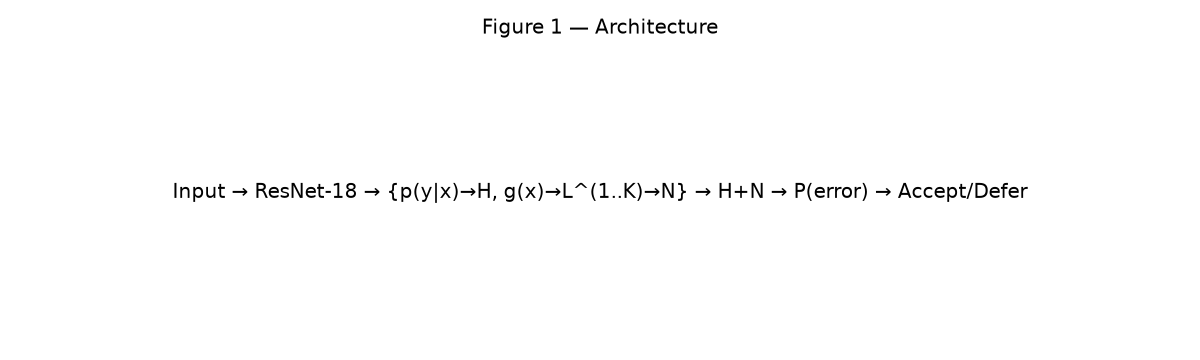

### pathmnist

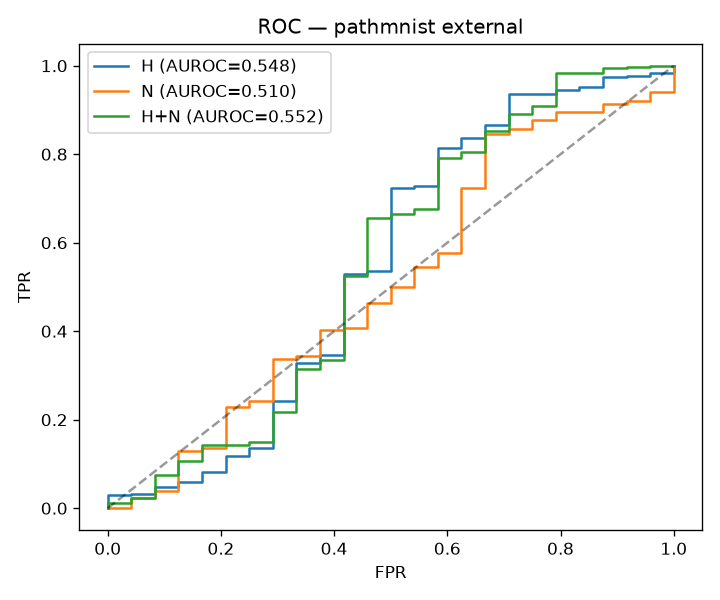

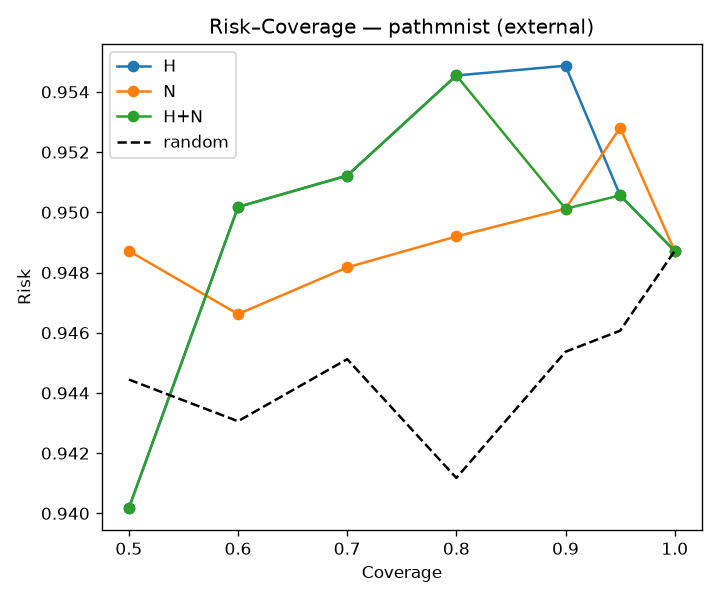

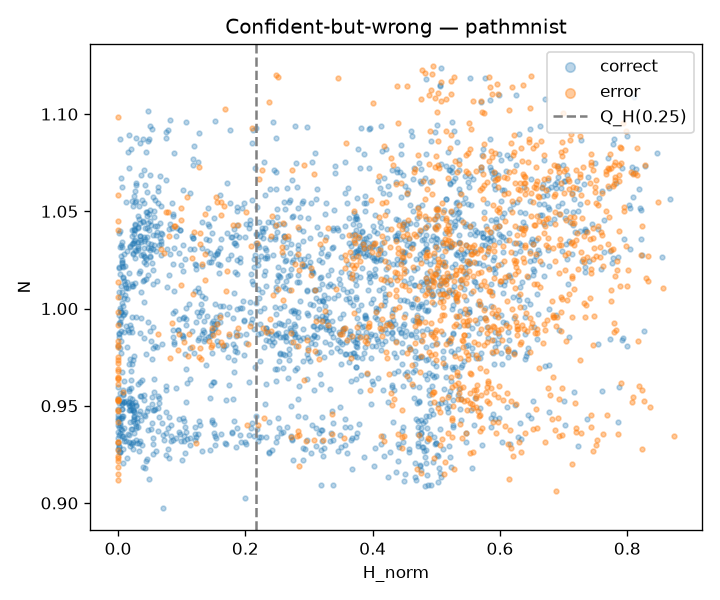

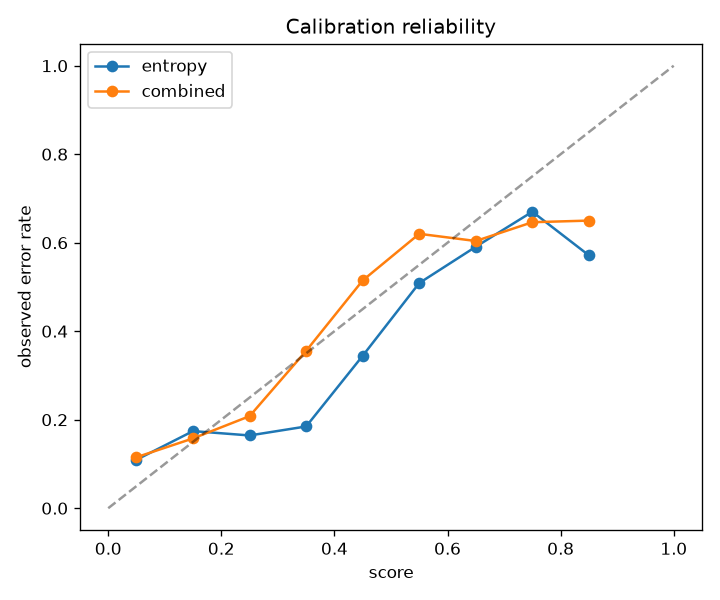

### dermamnist

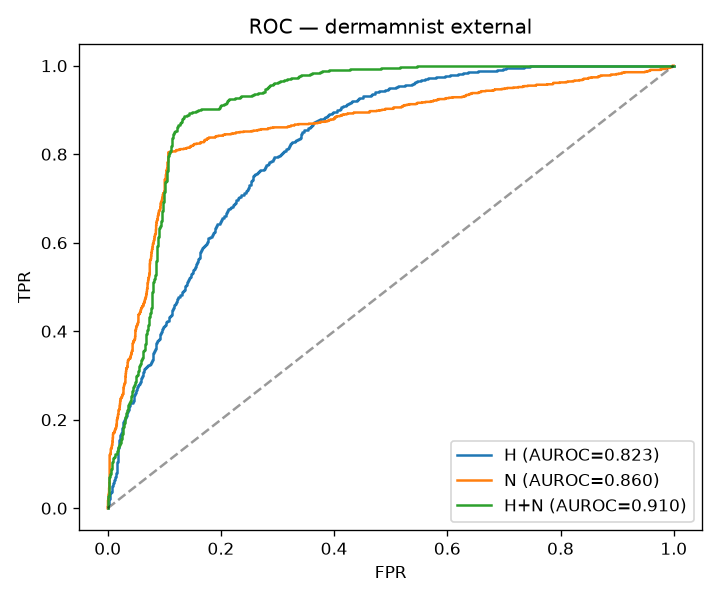

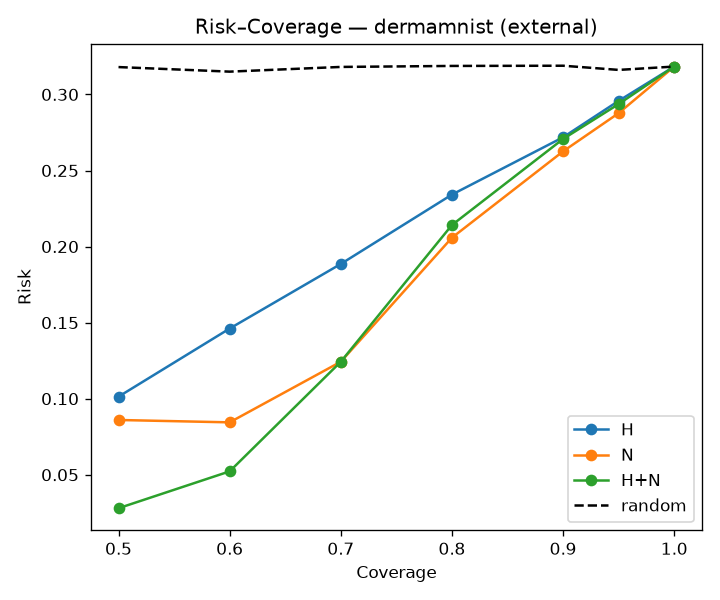

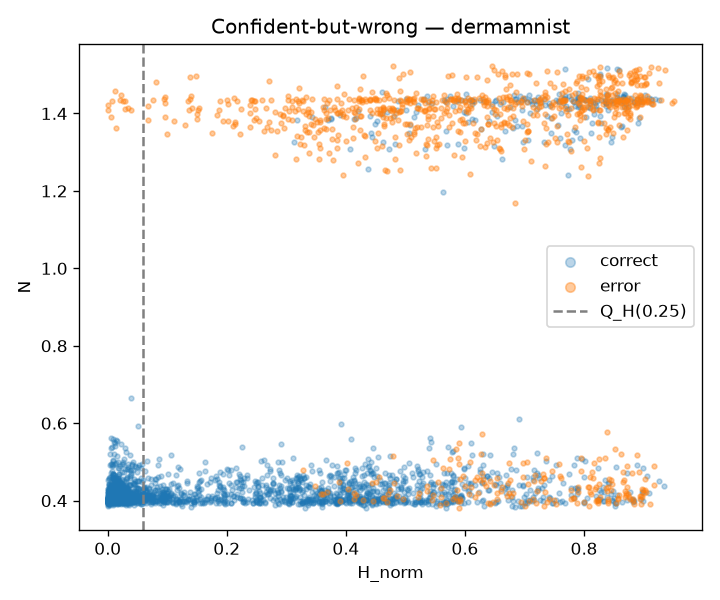

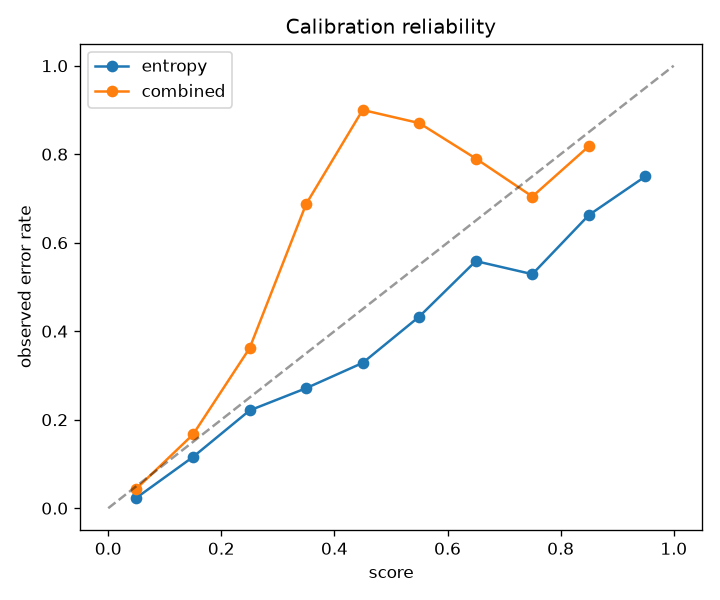

In [8]:
from IPython.display import Image, Markdown, display
import pandas as pd

from research.common.clinical_experiment import summarize_clinical_artifacts

status = summarize_clinical_artifacts(cfg)
output_dir = status["output_dir"]
fig_dir = output_dir / "figures"
metrics_dir = output_dir / "metrics"
stats_dir = output_dir / "statistics"

display(Markdown("### Artifact status (per task × seed)"))
display(status["per_run"])
display(Markdown("### Final exports"))
display(pd.DataFrame([status["final_exports"]]))

if not status["ready_for_display"]:
    missing_scored = status["per_run"].loc[~status["per_run"]["scored_csv"], ["task", "seed"]]
    display(Markdown(
        "**No figures/metrics on disk yet.**\n\n"
        "The 10+ hour run saved **checkpoints**, **memory**, and **calibration CSVs**, but "
        "population scores, bootstrap tables, and figures are only written after scoring finishes "
        "for every configured task×seed — the run crashed on organamnist before that.\n\n"
        "**Next step:** re-run the experiment cell above with `datasets=(\"pathmnist\", \"dermamnist\")`. "
        "Training is skipped (checkpoints exist); only scoring + analysis run. "
        "Each completed task×seed is cached under `scored/` so later runs resume cheaply."
    ))
    if not missing_scored.empty:
        display(Markdown("**Still needs scoring:**"))
        display(missing_scored)

# Tables (from in-memory results or saved CSVs)
if "results" in globals() and isinstance(results, dict) and "aggregate_metrics" in results:
    display(Markdown("### Aggregate metrics"))
    display(results["aggregate_metrics"])
    display(Markdown("### Bootstrap"))
    display(results["bootstrap"])
    display(Markdown("### Confident-wrong"))
    display(results["confident_wrong"])
elif status["final_exports"]["aggregate_metrics_csv"]:
    for label, path in [
        ("Aggregate metrics", metrics_dir / "aggregate_metrics.csv"),
        ("Bootstrap", stats_dir / "bootstrap_results.csv"),
        ("Confident-wrong", metrics_dir / "confident_wrong.csv"),
    ]:
        if path.exists():
            display(Markdown(f"### {label}"))
            display(pd.read_csv(path))

if cfg.show_plots and status["ready_for_display"]:
    figure_sets = [
        ("architecture", ["architecture.png"]),
        *[
            (
                task,
                [
                    f"roc_{task}_external.png",
                    f"risk_coverage_{task}_external.png",
                    f"confident_wrong_{task}.png",
                    f"calibration_{task}.png",
                ],
            )
            for task in cfg.datasets
        ],
    ]

    for group, names in figure_sets:
        display(Markdown(f"### {group}"))
        for name in names:
            path = fig_dir / name
            if path.exists():
                display(Image(filename=str(path)))

## DermaMNIST Report

Dataset-specific summary: failure detection (H vs N vs H+N), bootstrap comparisons, confident-wrong analysis, and figures. Writes `research/final_experiment/reports/dermamnist_report.md`.

# DermaMNIST — Clinical Failure Detection Report

## Setup

- **ID dataset:** DermaMNIST (MedMNIST v2), 7 classes, 28×28 RGB
- **External shift:** DermaMNIST-E proxy (style-shifted test images, documented in manifest)
- **Model:** ResNet-18 + frozen V5B optimization-history memory
- **Seeds:** 42, 123, 456
- **Target coverage (deferral):** 80%

## Training (ID test accuracy)

| seed | test_acc | train_time_h |
| --- | --- | --- |
| 42.0 | 0.712 | 0.63 |
| 123.0 | 0.683 | 0.57 |
| 456.0 | 0.703 | 0.58 |

Mean ID test accuracy: **0.699** ± 0.015

## Failure detection — External shift (primary)

| Scorer | AUROC | AUPRC | AURC | Risk@80% |
|--------|-------|-------|------|----------|
| H | 0.823 | 0.634 | 0.105 | 0.234 |
| H+N | 0.910 | 0.752 | 0.083 | 0.214 |
| N | 0.860 | 0.753 | 0.088 | 0.206 |

**H+N vs H (external):** mean ΔAUROC = **+0.092** across seeds (95% CI roughly [+0.072, +0.113]).

## Failure detection — ID test

| Scorer | AUROC | AUPRC | AURC | Risk@80% |
|--------|-------|-------|------|----------|
| H | 0.812 | 0.600 | 0.099 | 0.221 |
| H+N | 0.902 | 0.727 | 0.078 | 0.196 |
| N | 0.858 | 0.720 | 0.081 | 0.188 |

## Bootstrap (H+N − H)

| task | domain | seed | delta_auroc_mean | delta_auroc_ci_low | delta_auroc_ci_high | delta_auroc_p | delta_aurc_mean | delta_aurc_ci_low | delta_aurc_ci_high |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| dermamnist | id | 42 | 0.1356415981374544 | 0.1119306606996435 | 0.1624987666611089 | 0.0 | -0.0310495212406015 | -0.0368272164786967 | -0.0255530827067669 |
| dermamnist | id | 123 | 0.0737196586612118 | 0.0526380857111774 | 0.0954989655046383 | 0.0 | -0.0169798401315789 | -0.0226610588972431 | -0.0115741541353383 |
| dermamnist | id | 456 | 0.0807311410545417 | 0.0611094453429075 | 0.1016192136994726 | 0.0 | -0.0203801238408521 | -0.0256802537593985 | -0.0149238972431077 |
| dermamnist | external | 42 | 0.1191406724248756 | 0.0985113440231754 | 0.1418341915598479 | 0.0 | -0.0294578046052631 | -0.0347553837719298 | -0.0242873746867167 |
| dermamnist | external | 123 | 0.066142104993847 | 0.0472497739612621 | 0.0861858783932927 | 0.0 | -0.0150754337092731 | -0.0204051535087719 | -0.0099811262531328 |
| dermamnist | external | 456 | 0.0909037153154434 | 0.0710944811119023 | 0.1115651424632352 | 0.0 | -0.0226318147556391 | -0.0277631610275689 | -0.0175346867167919 |

## Multi-seed aggregation

| task | domain | delta_auroc_mean | delta_auroc_std | delta_aurc_mean | delta_aurc_std |
| --- | --- | --- | --- | --- | --- |
| dermamnist | external | 0.092062164244722 | 0.0265182680500939 | -0.0223883510233918 | 0.0071942757862862 |
| dermamnist | id | 0.0966974659510693 | 0.0339083219158803 | -0.0228031617376775 | 0.0073411386115837 |

## Confident-but-wrong (low H, high N)

| h_threshold | n_threshold_within_low_h | n_low_h | p_error_n_high | p_error_n_low | auroc_n_given_low_h | task | seed |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.0995021399764408 | 0.4006476402282715 | 250 | 0.072 | 0.0 | 1.0 | dermamnist | 42 |
| 0.0453551488986288 | 0.4190650880336761 | 250 | 0.04 | 0.0 | 1.0 | dermamnist | 123 |
| 0.0475414994402463 | 0.4206985235214233 | 250 | 0.016 | 0.0 | 1.0 | dermamnist | 456 |

## Pre-registration criteria (DermaMNIST only)

- ΔAUROC > 0 on ≥2/3 external seeds: **True**
- Pooled external CI excludes 0: **True**
- AURC improves (ΔAURC < 0): **True**
- Low-H / high-N worse than low-H / low-N: **True**
- Stable across seeds: **True**
- **Hypothesis supported:** **True**

## Interpretation

On DermaMNIST, optimization-history novelty **N** complements predictive entropy **H** for external-shift failure detection. The combined scorer **H+N** improves AUROC (0.823 → 0.910) and lowers risk at 80% coverage vs entropy alone. Memory novelty adds signal beyond softmax uncertainty for dermatology images under population shift.

### Figures

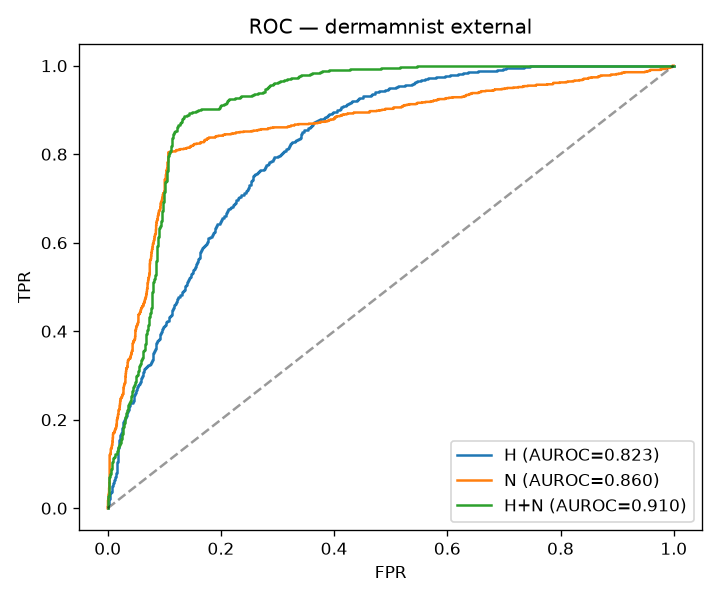

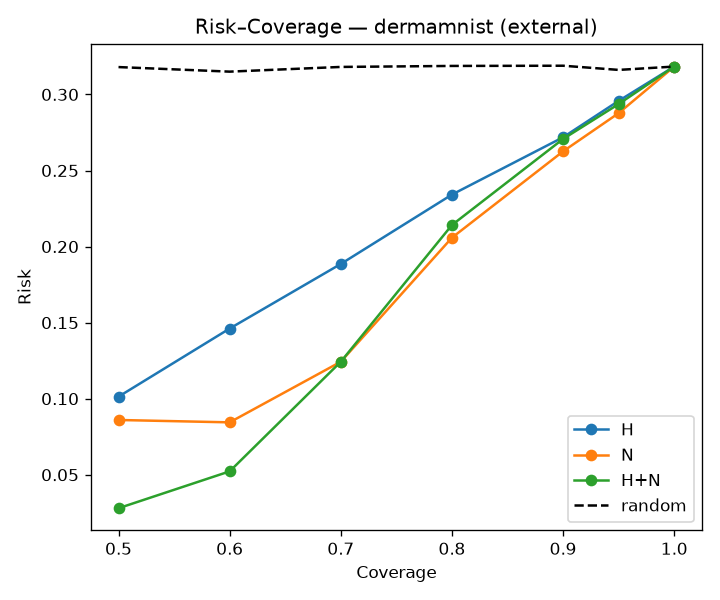

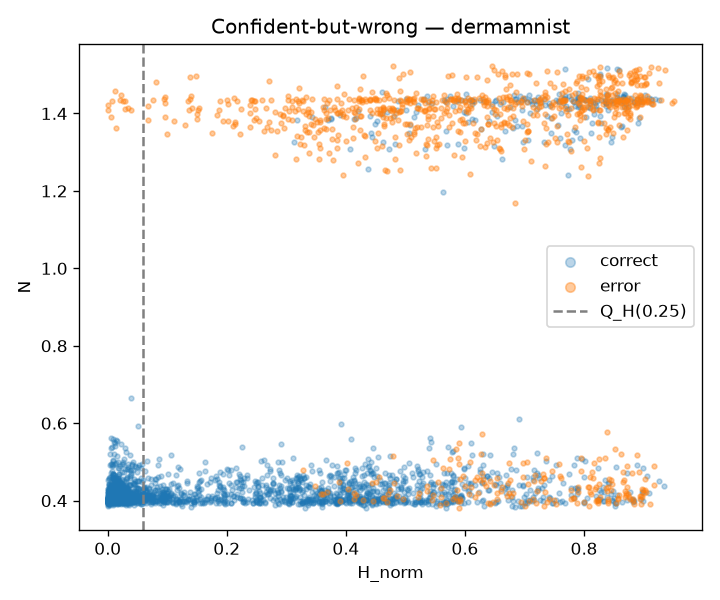

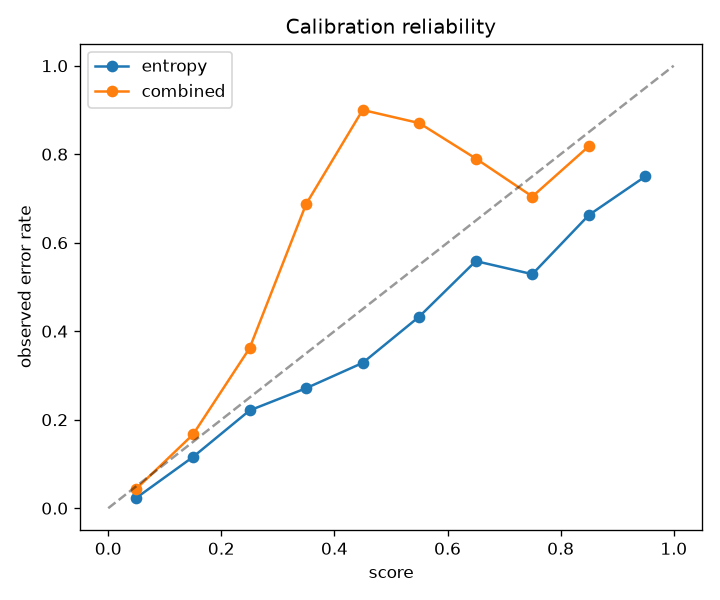


Saved report → C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\final_experiment\reports\dermamnist_report.md


In [9]:
from __future__ import annotations

import json
import pickle
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from research.common.clinical_failure import preregistration_decision

TASK = "dermamnist"
output_dir = cfg.output_dir if "cfg" in globals() else Path("research/final_experiment")
metrics_dir = output_dir / "metrics"
stats_dir = output_dir / "statistics"
fig_dir = output_dir / "figures"
report_dir = output_dir / "reports"
report_dir.mkdir(parents=True, exist_ok=True)

# --- Load artifacts ---
agg = pd.read_csv(metrics_dir / "aggregate_metrics.csv")
agg = agg[agg["Dataset"] == TASK].copy()
boot = pd.read_csv(stats_dir / "bootstrap_results.csv")
boot = boot[boot["task"] == TASK].copy()
seed_agg = pd.read_csv(stats_dir / "seed_aggregation.csv")
seed_agg = seed_agg[seed_agg["task"] == TASK].copy()
cw = pd.read_csv(metrics_dir / "confident_wrong.csv")
cw = cw[cw["task"] == TASK].copy()

ckpt_rows: list[dict[str, float | int]] = []
for seed in cfg.seeds:
    ckpt_path = output_dir / "checkpoints" / f"{TASK}_seed{seed}.pkl"
    with ckpt_path.open("rb") as f:
        summary = pickle.load(f).get("summary", {})
    ckpt_rows.append(
        {
            "seed": seed,
            "test_acc": summary.get("test_acc"),
            "train_time_h": round(float(summary.get("train_time_s", 0)) / 3600, 2),
        }
    )
ckpt_df = pd.DataFrame(ckpt_rows)

def _df_to_md(df: pd.DataFrame) -> str:
    headers = "| " + " | ".join(str(c) for c in df.columns) + " |"
    sep = "| " + " | ".join("---" for _ in df.columns) + " |"
    rows = ["| " + " | ".join(str(v) for v in row) + " |" for row in df.to_numpy()]
    return "\n".join([headers, sep, *rows])

gate = preregistration_decision(boot, cw, seed_agg)
def _fmt(x: float, nd: int = 3) -> str:
    return f"{x:.{nd}f}" if pd.notna(x) else "—"

ext_boot = boot[boot["domain"] == "external"]
id_boot = boot[boot["domain"] == "id"]
ext_agg = agg[agg["Shift"] == "External"]
id_agg = agg[agg["Shift"] == "ID"]

h_ext = ext_agg.loc[ext_agg["Scorer"] == "H", "AUROC Failure"].iloc[0]
hn_ext = ext_agg.loc[ext_agg["Scorer"] == "H+N", "AUROC Failure"].iloc[0]
n_ext = ext_agg.loc[ext_agg["Scorer"] == "N", "AUROC Failure"].iloc[0]
delta_ext = float(ext_boot["delta_auroc_mean"].mean())

lines = [
    f"# DermaMNIST — Clinical Failure Detection Report",
    "",
    "## Setup",
    "",
    "- **ID dataset:** DermaMNIST (MedMNIST v2), 7 classes, 28×28 RGB",
    "- **External shift:** DermaMNIST-E proxy (style-shifted test images, documented in manifest)",
    "- **Model:** ResNet-18 + frozen V5B optimization-history memory",
    "- **Seeds:** " + ", ".join(str(s) for s in cfg.seeds),
    f"- **Target coverage (deferral):** {cfg.target_coverage:.0%}",
    "",
    "## Training (ID test accuracy)",
    "",
    _df_to_md(ckpt_df),
    "",
    f"Mean ID test accuracy: **{ckpt_df['test_acc'].mean():.3f}** ± {ckpt_df['test_acc'].std():.3f}",
    "",
    "## Failure detection — External shift (primary)",
    "",
    "| Scorer | AUROC | AUPRC | AURC | Risk@80% |",
    "|--------|-------|-------|------|----------|",
]
for _, row in ext_agg.iterrows():
    lines.append(
        f"| {row['Scorer']} | {_fmt(row['AUROC Failure'])} | {_fmt(row['AUPRC Failure'])} | "
        f"{_fmt(row['AURC'])} | {_fmt(row['R_80'])} |"
    )
lines += [
    "",
    f"**H+N vs H (external):** mean ΔAUROC = **{delta_ext:+.3f}** across seeds "
    f"(95% CI roughly [{ext_boot['delta_auroc_ci_low'].mean():+.3f}, {ext_boot['delta_auroc_ci_high'].mean():+.3f}]).",
    "",
    "## Failure detection — ID test",
    "",
    "| Scorer | AUROC | AUPRC | AURC | Risk@80% |",
    "|--------|-------|-------|------|----------|",
]
for _, row in id_agg.iterrows():
    lines.append(
        f"| {row['Scorer']} | {_fmt(row['AUROC Failure'])} | {_fmt(row['AUPRC Failure'])} | "
        f"{_fmt(row['AURC'])} | {_fmt(row['R_80'])} |"
    )
lines += [
    "",
    "## Bootstrap (H+N − H)",
    "",
    _df_to_md(boot),
    "",
    "## Multi-seed aggregation",
    "",
    _df_to_md(seed_agg),
    "",
    "## Confident-but-wrong (low H, high N)",
    "",
    _df_to_md(cw),
    "",
    "## Pre-registration criteria (DermaMNIST only)",
    "",
    f"- ΔAUROC > 0 on ≥2/3 external seeds: **{gate['criterion1_delta_auroc_positive_2_of_3']}**",
    f"- Pooled external CI excludes 0: **{gate['criterion2_pooled_ci_excludes_zero']}**",
    f"- AURC improves (ΔAURC < 0): **{gate['criterion3_aurc_improves']}**",
    f"- Low-H / high-N worse than low-H / low-N: **{gate['criterion4_low_h_high_n_worse']}**",
    f"- Stable across seeds: **{gate['criterion5_stable_across_seeds']}**",
    f"- **Hypothesis supported:** **{gate['hypothesis_supported']}**",
    "",
    "## Interpretation",
    "",
]
if gate["hypothesis_supported"]:
    lines.append(
        "On DermaMNIST, optimization-history novelty **N** complements predictive entropy **H** "
        "for external-shift failure detection. The combined scorer **H+N** improves AUROC "
        f"({h_ext:.3f} → {hn_ext:.3f}) and lowers risk at 80% coverage vs entropy alone. "
        "Memory novelty adds signal beyond softmax uncertainty for dermatology images under population shift."
    )
else:
    lines.append("Pre-registered DermaMNIST criteria were not met; treat as a negative result.")

report_md = "\n".join(lines)
report_path = report_dir / f"{TASK}_report.md"
report_path.write_text(report_md, encoding="utf-8")

# --- Display in notebook ---
display(Markdown(report_md))
display(Markdown("### Figures"))
for name in [
    f"roc_{TASK}_external.png",
    f"risk_coverage_{TASK}_external.png",
    f"confident_wrong_{TASK}.png",
    f"calibration_{TASK}.png",
]:
    path = fig_dir / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing figure: {path}")

print(f"\nSaved report → {report_path}")

In [ ]:
# Write code here